 ## Distribution of Cosine Similarities

In [1]:
import sys
print(sys.executable)

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\python.exe


In [2]:
import torch
print(torch.__version__)

2.11.0+cpu


In [3]:
from transformers import GPT2Model, GPT2Tokenizer
print("Transformers ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers ready!


In [4]:
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

print("GPT2 load ho gaya!")
print(f"Embedding size: {model.config.n_embd}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\devuser3\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6246.80it/s]

GPT2 load ho gaya!
Embedding size: 768


In [5]:
import torch

text = "Hello, how are you doing today?"

# Tokenize karo
inputs = tokenizer(text, return_tensors="pt")

# Embeddings nikalo
with torch.no_grad():
    outputs = model(**inputs)

# Last hidden state = embeddings
embeddings = outputs.last_hidden_state

print(f"Input text: {text}")
print(f"Tokens: {inputs['input_ids'].shape[1]}")
print(f"Embedding shape: {embeddings.shape}")
print(f"\nShape matlab: [batch, tokens, embedding_size]")

Input text: Hello, how are you doing today?
Tokens: 8
Embedding shape: torch.Size([1, 8, 768])

Shape matlab: [batch, tokens, embedding_size]


In [6]:
from torch.nn.functional import cosine_similarity

# Saare token embeddings nikalo
token_embeddings = embeddings[0]  # shape: [8, 768]

# Token names dekho
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
print("Tokens:", tokens)

# Har pair ki cosine similarity
n = len(tokens)
sim_matrix = torch.zeros(n, n)

for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(
            token_embeddings[i].unsqueeze(0),
            token_embeddings[j].unsqueeze(0)
        )

print("\nSimilarity Matrix shape:", sim_matrix.shape)
print(sim_matrix.round(decimals=2))

Tokens: ['Hello', ',', 'Ġhow', 'Ġare', 'Ġyou', 'Ġdoing', 'Ġtoday', '?']

Similarity Matrix shape: torch.Size([8, 8])
tensor([[1.0000, 0.9600, 0.9400, 0.9300, 0.9400, 0.9600, 0.9600, 0.9600],
        [0.9600, 1.0000, 1.0000, 0.9900, 0.9900, 1.0000, 0.9900, 1.0000],
        [0.9400, 1.0000, 1.0000, 1.0000, 1.0000, 0.9900, 0.9800, 0.9900],
        [0.9300, 0.9900, 1.0000, 1.0000, 0.9900, 0.9900, 0.9800, 0.9800],
        [0.9400, 0.9900, 1.0000, 0.9900, 1.0000, 0.9900, 0.9800, 0.9800],
        [0.9600, 1.0000, 0.9900, 0.9900, 0.9900, 1.0000, 0.9900, 0.9900],
        [0.9600, 0.9900, 0.9800, 0.9800, 0.9800, 0.9900, 1.0000, 0.9900],
        [0.9600, 1.0000, 0.9900, 0.9800, 0.9800, 0.9900, 0.9900, 1.0000]])


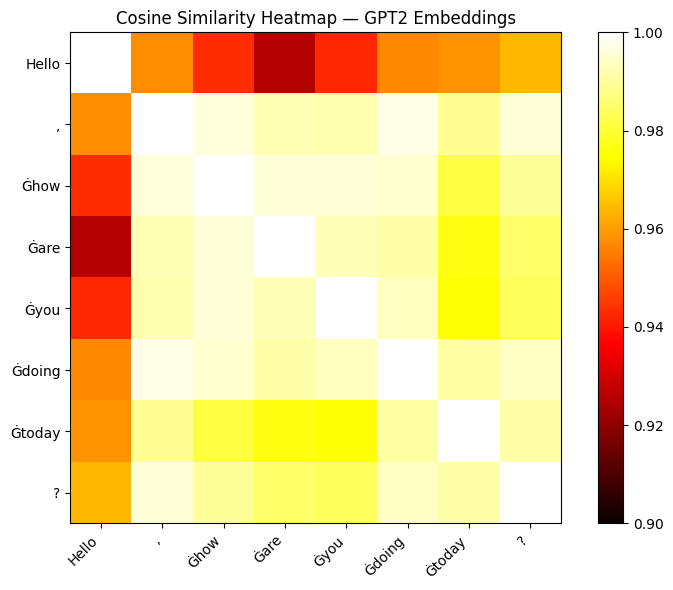

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(sim_matrix.numpy(), cmap="hot", vmin=0.9, vmax=1.0)

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)

plt.colorbar(im)
ax.set_title("Cosine Similarity Heatmap — GPT2 Embeddings")

plt.tight_layout()
plt.show()

* Each token is represented as a **vector of 768 numbers** (an embedding).

* **Cosine similarity** (Cosine Similarity) is used to measure how close two tokens are in meaning.

* Tokens within the **same sentence tend to be very similar**, usually in the range of **0.93 to 1.0**.

* The token **"Hello"** appeared the most different, likely because it behaves like a **standalone or proper noun-like token**, making it less contextually similar to others.
